In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [11]:
import pandas as pd

columns = (
    ["engine_id", "cycle"]
    + [f"op_setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train = pd.read_csv(
    "data/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns,
)

test = pd.read_csv(
    "data/test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns,
)

rul = pd.read_csv(
    "data/RUL_FD001.txt",
    header=None,
    names=["RUL"],              # RUL = Remaining Useful Life
)

In [15]:
rul.head(50)

,RUL
0,112
1,98
2,69
3,82
4,91
5,93
6,91
7,95
8,111
9,96


In [3]:
print(train.shape)
print(test.shape)
print(rul.shape)

(20631, 26)
(13096, 26)
(100, 1)


In [4]:
# train.duplicated().sum()
# test.duplicated().sum()
rul.duplicated().sum()

np.int64(29)

In [5]:
engine_cycles = (
    train.groupby("engine_id")["cycle"]
         .max()
         .reset_index()
)

engine_cycles.head()

,engine_id,cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


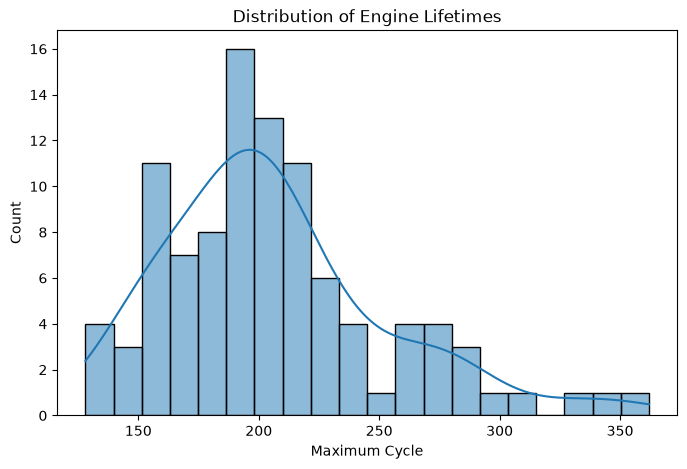

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    engine_cycles["cycle"],
    bins=20,
    kde=True
)

plt.title("Distribution of Engine Lifetimes")
plt.xlabel("Maximum Cycle")
plt.ylabel("Count")

plt.show()

In [10]:
train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [8]:
operating = [
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

train[operating].describe()

,op_setting_1,op_setting_2,op_setting_3
count,20631.000000,20631.000000,20631.0
mean,-0.000009,0.000002,100.0
std,0.002187,0.000293,0.0
min,-0.008700,-0.000600,100.0
25%,-0.001500,-0.000200,100.0
50%,0.000000,0.000000,100.0
75%,0.001500,0.000300,100.0
max,0.008700,0.000600,100.0


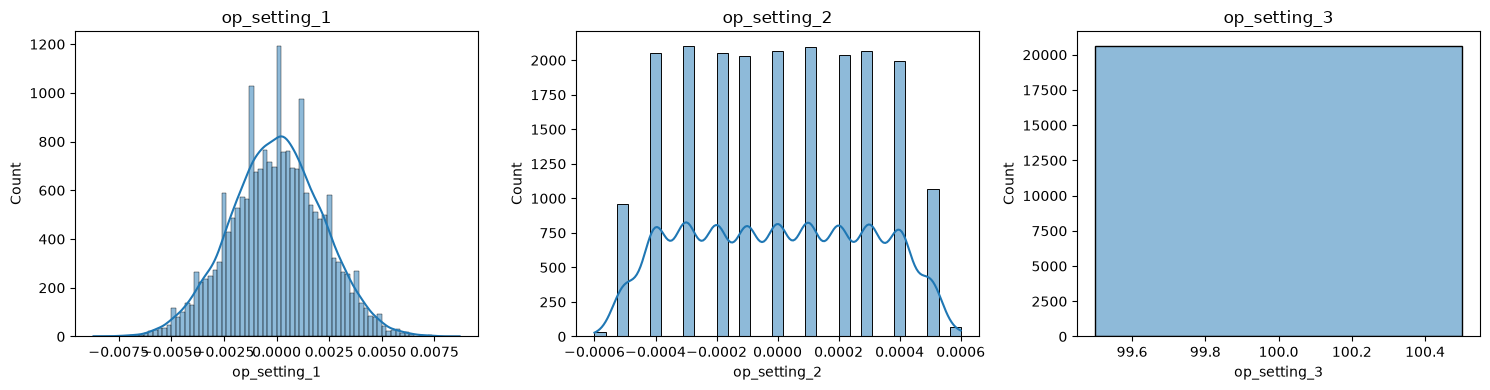

In [9]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

for i, col in enumerate(operating):

    sns.histplot(
        train[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [11]:
sensor_cols = [f"sensor_{i}" for i in range(1,22)]

train[sensor_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sensor_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200
sensor_6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
sensor_7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
sensor_8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
sensor_9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
sensor_10,20631.0,1.300000,4.660829e-13,1.3000,1.3000,1.3000,1.3000,1.3000


In [12]:
constant_sensors = []

for col in sensor_cols:

    if train[col].nunique() == 1:
        constant_sensors.append(col)

constant_sensors

['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

In [14]:
variance = (
    train[sensor_cols]
    .var()
    .sort_values()
)

variance

sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    2.422479e-28
sensor_10    2.172333e-25
sensor_5     1.152399e-23
sensor_1     4.273435e-21
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
sensor_17    2.398667e+00
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_14    3.639005e+02
sensor_9     4.876536e+02
dtype: float64

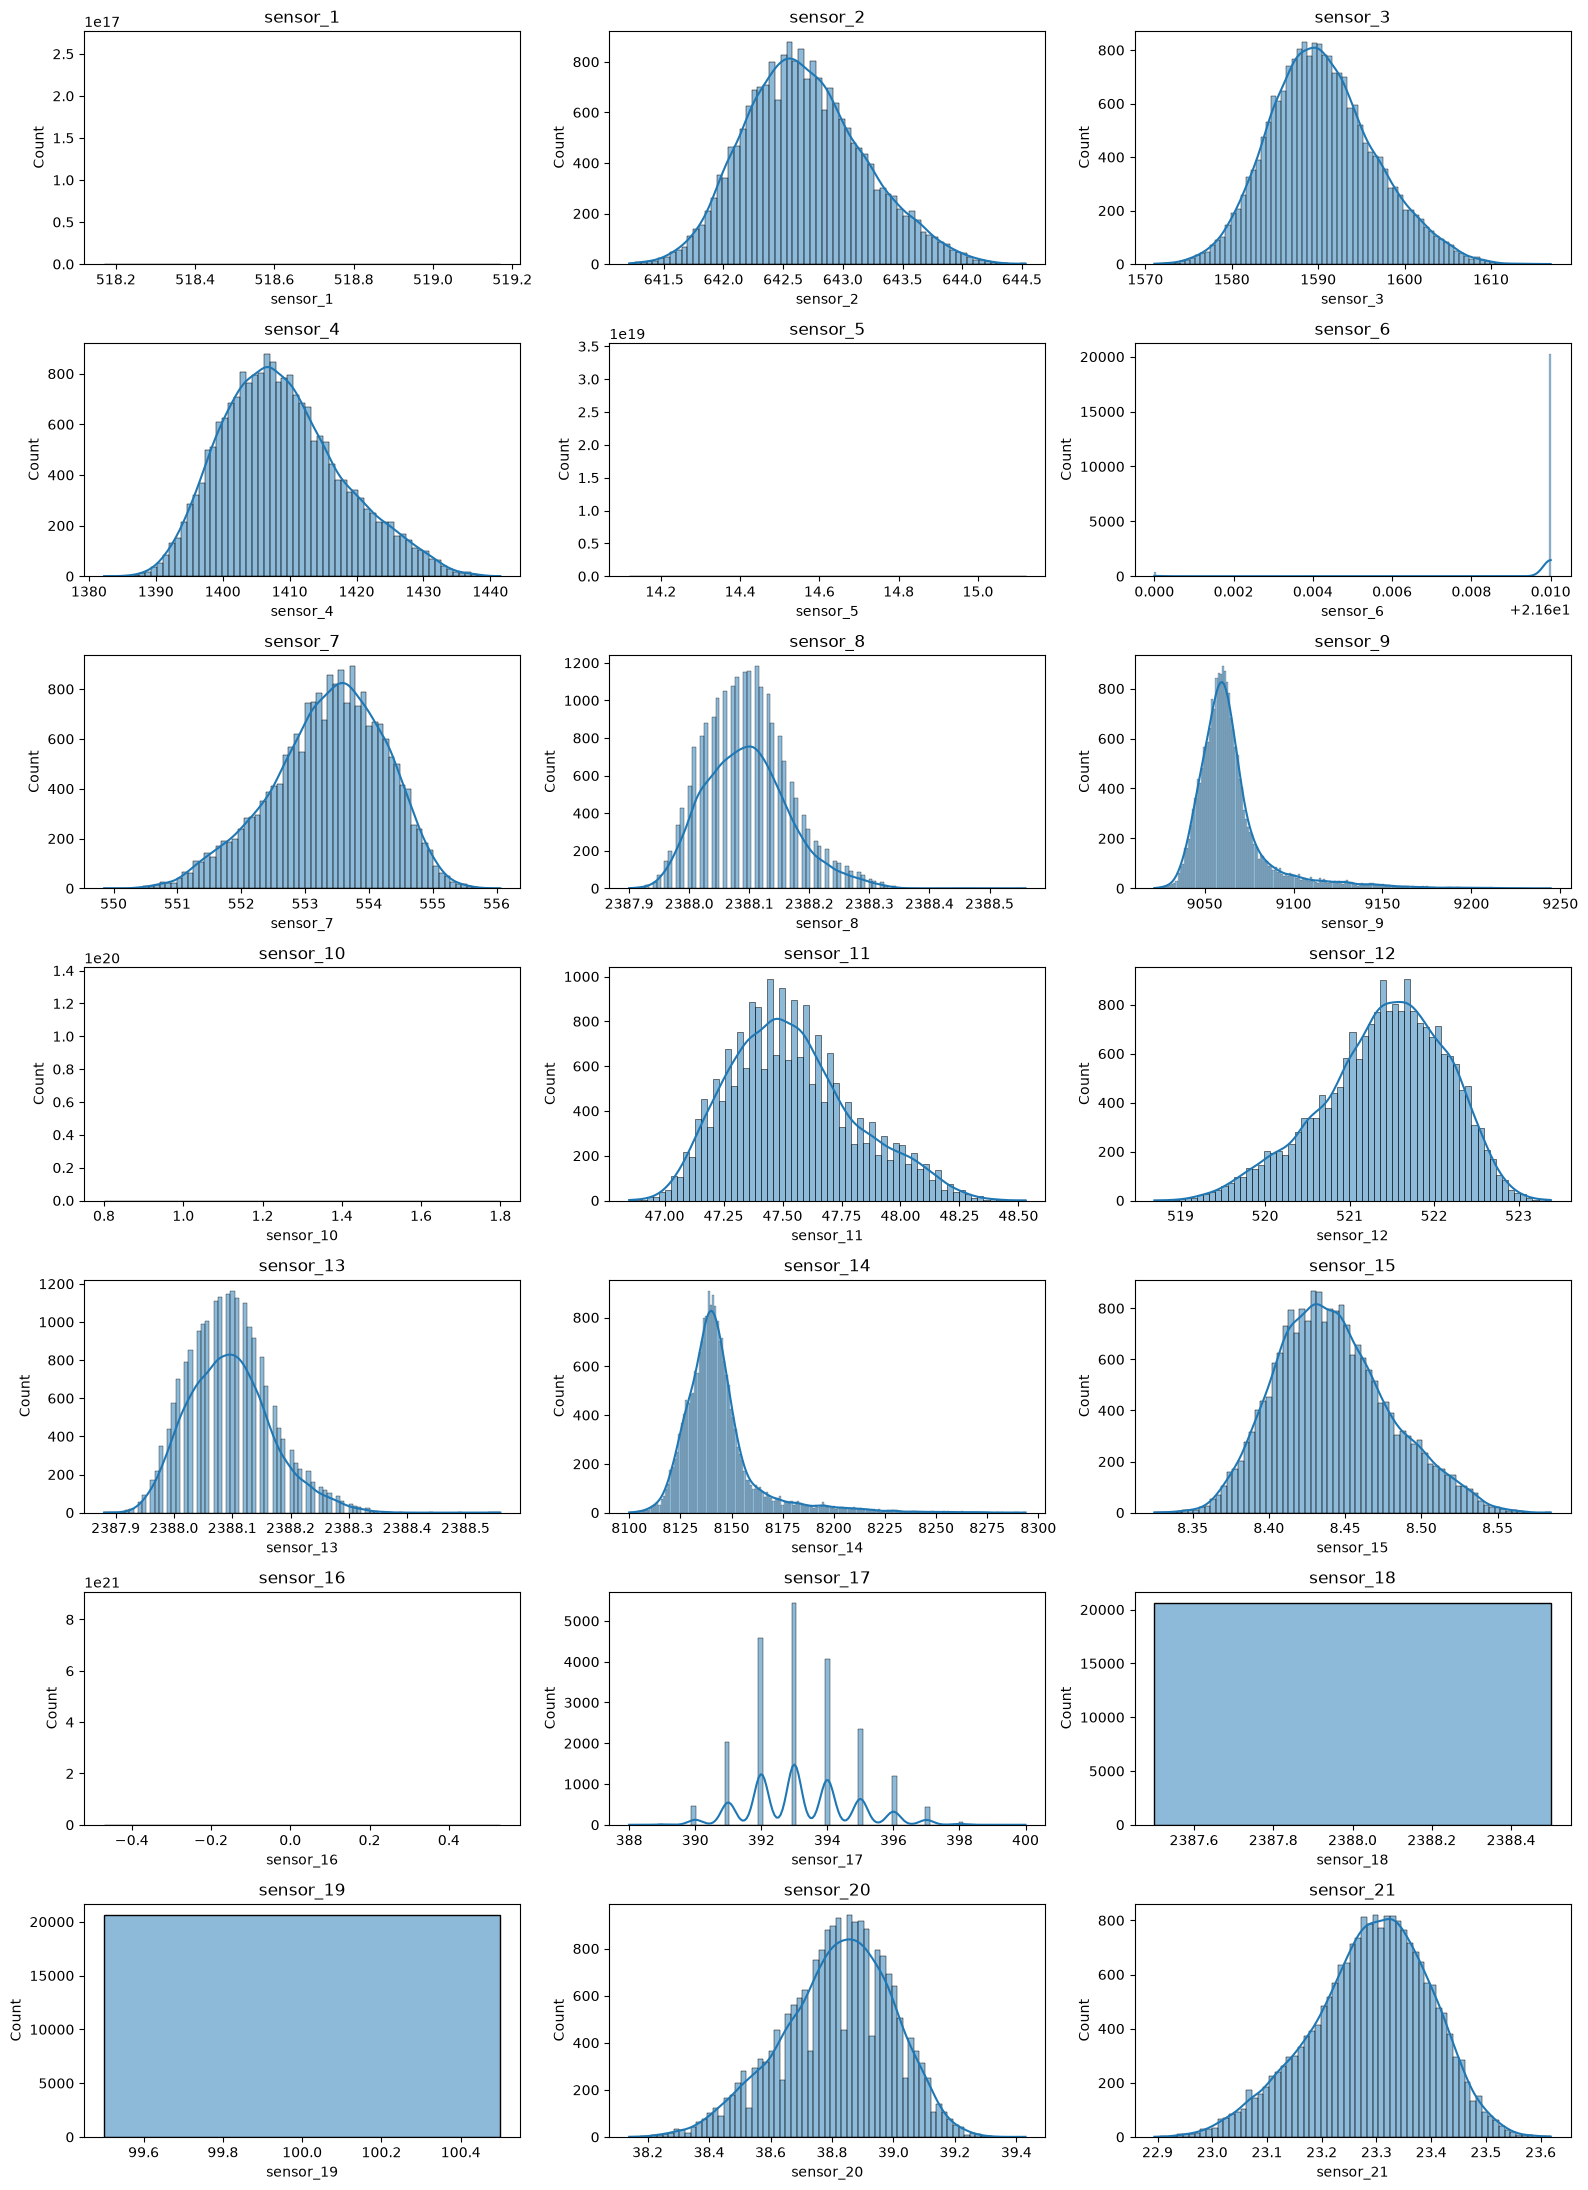

In [15]:
fig, axes = plt.subplots(7, 3, figsize=(16,22))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):

    sns.histplot(
        train[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [16]:
engine = train[train["engine_id"] == 1]

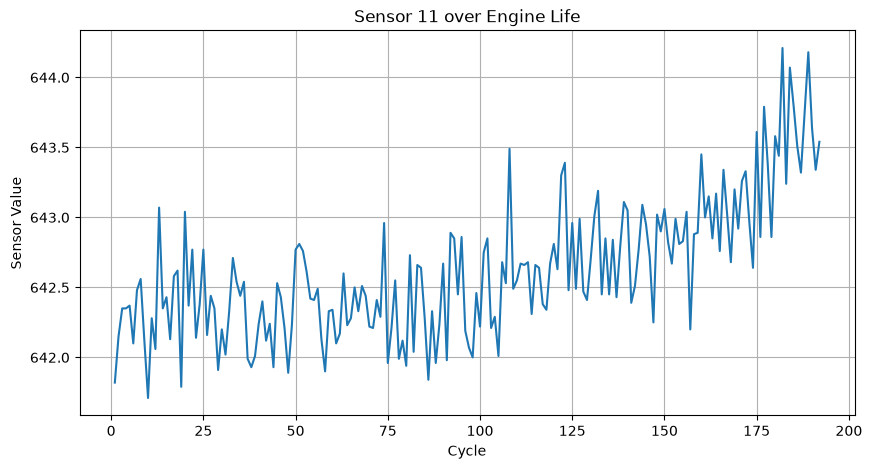

In [21]:
plt.figure(figsize=(10,5))

plt.plot(
    engine["cycle"],
    engine["sensor_2"]
)

plt.title("Sensor 11 over Engine Life")
plt.xlabel("Cycle")
plt.ylabel("Sensor Value")

plt.grid(True)

plt.show()

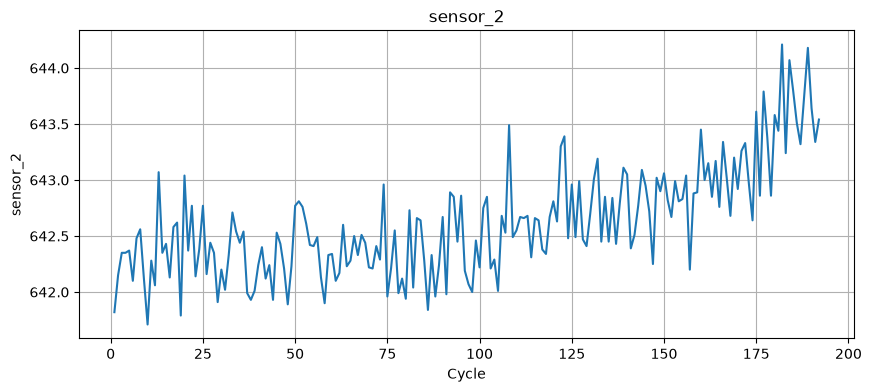

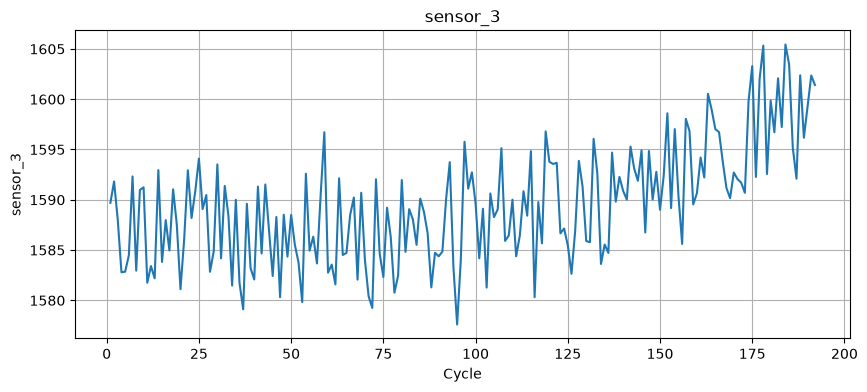

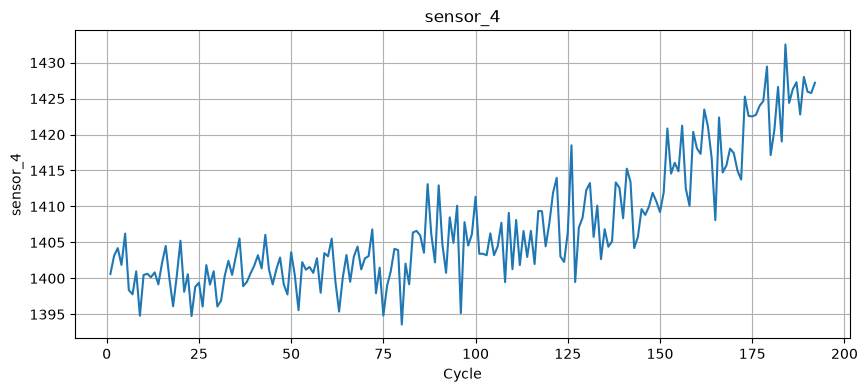

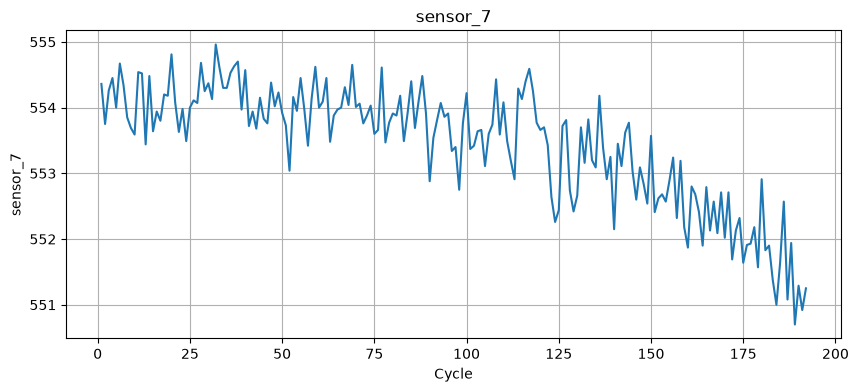

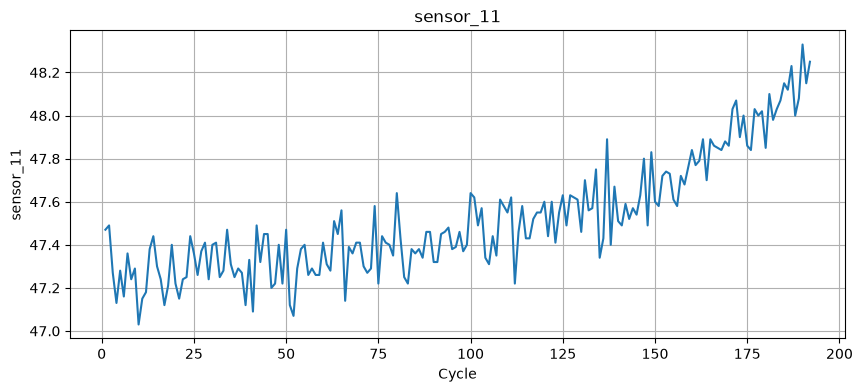

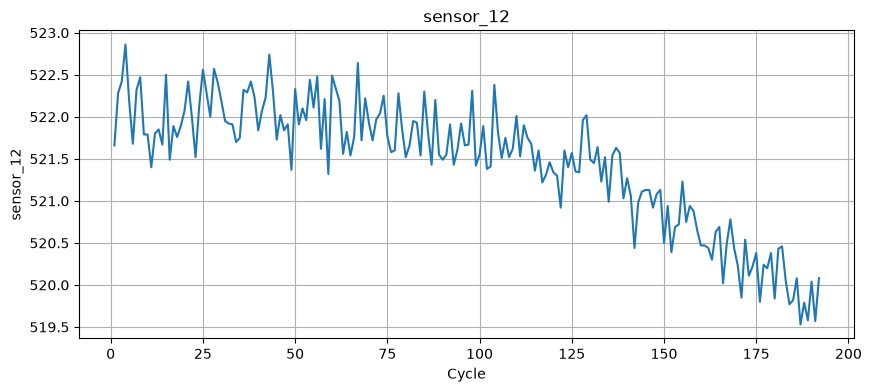

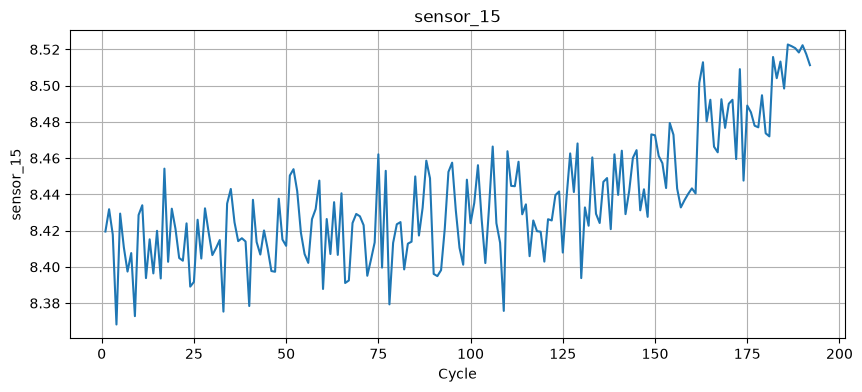

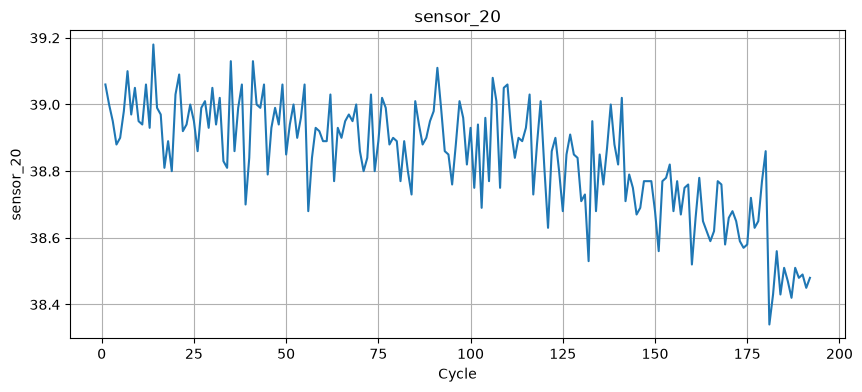

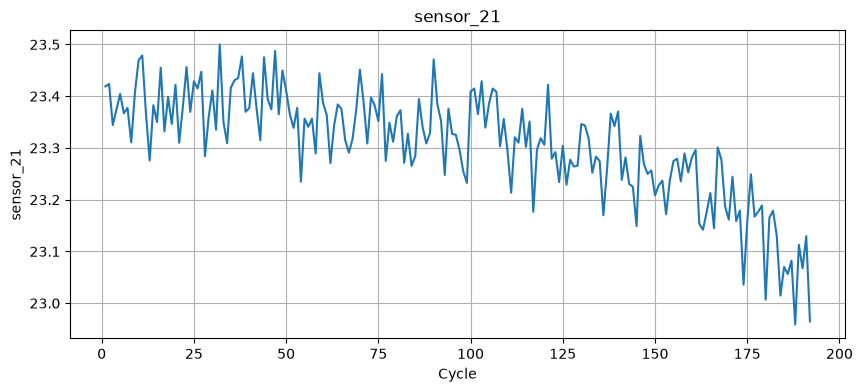

In [26]:
important = [
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_7",
    "sensor_11",
    "sensor_12",
    "sensor_15",
    "sensor_20",
    "sensor_21"
]

for sensor in important:

    plt.figure(figsize=(10,4))

    plt.plot(
        engine["cycle"],
        engine[sensor]
    )

    plt.title(sensor)

    plt.xlabel("Cycle")
    plt.ylabel(sensor)

    plt.grid(True)

    plt.show()

In [22]:
train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
